Analysis of Topic Modeling

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Fix CJK fonts
for fname in ["Arial Unicode MS", "PingFang SC", "STHeiti"]:
    if any(fname in f.name for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = fname
        break

PERIOD_ORDER = ["pre_joseon", "early_joseon", "mid_joseon", "late_joseon", "final_joseon"]

In [2]:
summary = pd.read_csv("../results/topics/topic_weights_by_period.csv", index_col=0)

with open("../results/topics/topics.json") as f:
    topics = json.load(f)

label_map = {f"topic_{t['topic_id']}_weight": t["label"] for t in topics}
summary = summary.rename(columns=label_map)
summary = summary.reindex(PERIOD_ORDER)
print(summary.round(4))

              weather_atmosphere  philosophical_reflection  banquet_leisure  \
period                                                                        
pre_joseon                0.0686                    0.0989           0.1309   
early_joseon              0.0832                    0.0812           0.0882   
mid_joseon                0.0637                    0.0940           0.0776   
late_joseon               0.0650                    0.0919           0.0761   
final_joseon              0.0591                    0.1138           0.0685   

              rural_reclusion  plum_winter_flowers  confucian_moral  \
period                                                                
pre_joseon             0.0481               0.0759           0.0474   
early_joseon           0.0611               0.0669           0.0453   
mid_joseon             0.0672               0.0541           0.0481   
late_joseon            0.0733               0.0547           0.0464   
final_joseon        

In [3]:
early = summary.loc["early_joseon"]
late  = summary.loc["late_joseon"]
delta = (late - early).sort_values(ascending=False)

print("=== GREW early → late Joseon ===")
print(delta.head(6).round(4))
print("\n=== SHRANK ===")
print(delta.tail(6).round(4))

=== GREW early → late Joseon ===
grief_lamentation           0.0189
mountain_daoist_retreat     0.0165
melancholy_exile            0.0165
literary_culture_tribute    0.0144
rural_reclusion             0.0122
philosophical_reflection    0.0107
dtype: float64

=== SHRANK ===
banquet_leisure            -0.0121
plum_winter_flowers        -0.0122
military_heroic            -0.0137
court_royal_encomium       -0.0172
weather_atmosphere         -0.0183
official_travel_farewell   -0.0225
dtype: float64


In [4]:
mid   = summary.loc["mid_joseon"]
final = summary.loc["final_joseon"]
delta2 = (final - mid).sort_values(ascending=False)

print("=== GREW mid → final Joseon ===")
print(delta2.head(6).round(4))
print("\n=== SHRANK ===")
print(delta2.tail(6).round(4))

=== GREW mid → final Joseon ===
literary_culture_tribute    0.0348
philosophical_reflection    0.0198
mountain_daoist_retreat     0.0078
grief_lamentation           0.0049
plum_winter_flowers         0.0030
court_royal_encomium        0.0029
dtype: float64

=== SHRANK ===
weather_atmosphere         -0.0046
rural_reclusion            -0.0047
banquet_leisure            -0.0092
military_heroic            -0.0137
river_waterscape           -0.0181
official_travel_farewell   -0.0183
dtype: float64


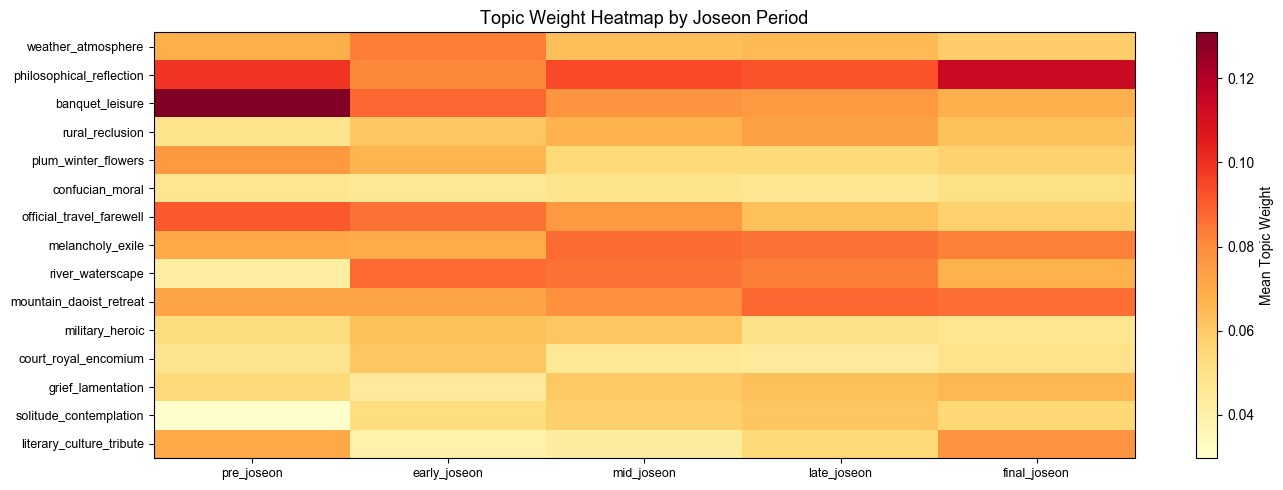

In [5]:
import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))
data = summary.loc[PERIOD_ORDER]
im = ax.imshow(data.T.values, aspect="auto", cmap="YlOrRd")

ax.set_xticks(range(len(PERIOD_ORDER)))
ax.set_xticklabels(PERIOD_ORDER, fontsize=9)
ax.set_yticks(range(len(data.columns)))
ax.set_yticklabels(data.columns, fontsize=9)
plt.colorbar(im, ax=ax, label="Mean Topic Weight")
ax.set_title("Topic Weight Heatmap by Joseon Period", fontsize=13)
plt.tight_layout()
plt.savefig("../results/topics/figures/topic_heatmap.png", dpi=150)
plt.show()

In [2]:
pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 11.0 MB/s eta 0:00:00 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
from statsmodels.stats.proportion import proportions_ztest

# 85.4% of 163,332 unlabeled KLC shi; 85.1% of 48,641 Tang shi
count = [int(0.854 * 163332), int(0.851 * 57607)]
nobs  = [163332, 57607]
stat, pval = proportions_ztest(count, nobs)
print(f"z = {stat:.2f}, p = {pval:.3f}")

z = 1.75, p = 0.080
